This is a companion notebook for the book [Deep Learning with Python, Third Edition](TODO). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

!pip install keras-nightly keras-hub-nightly --upgrade -q

In [90]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [1]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

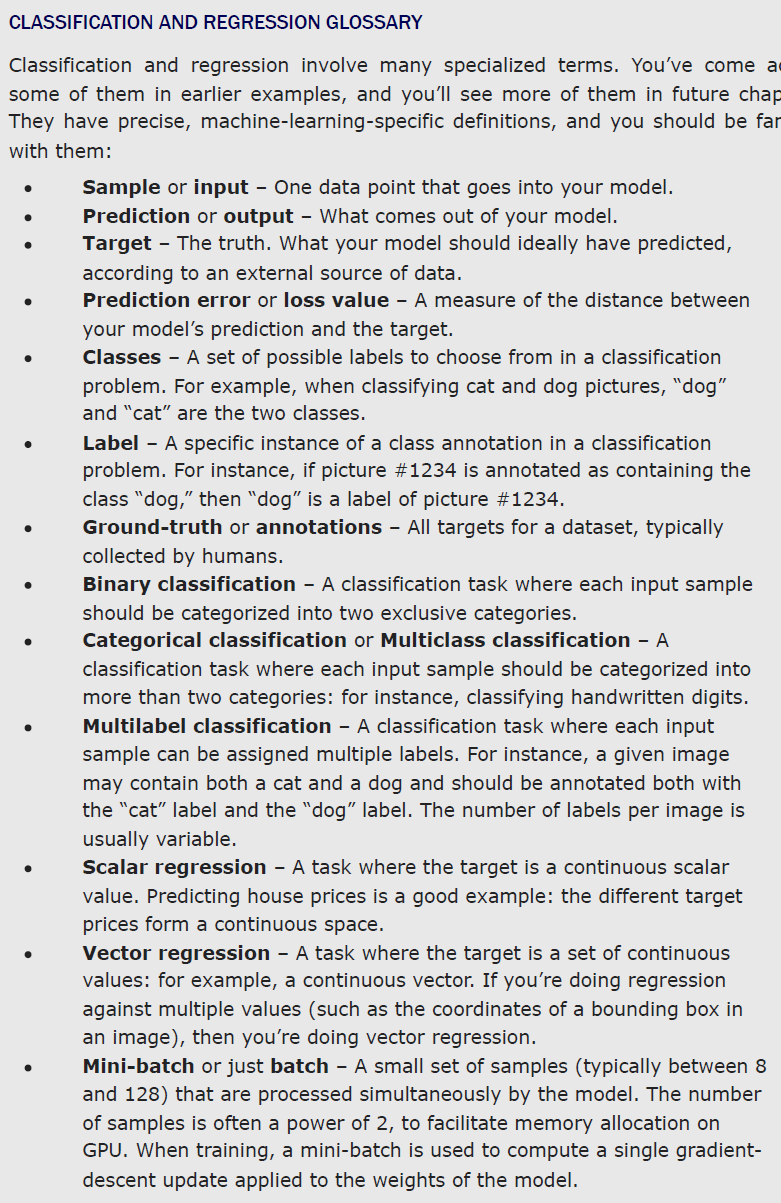

### Classifying movie reviews: a binary classification example

Two-class classification, or binary classification, is one of the most common kinds of
machine-learning problem. In this example, you’ll learn to classify movie reviews as
positive or negative, based on the text content of the reviews.

#### The IMDb dataset

You’ll work with the IMDb dataset: a set of 50,000 highly polarized reviews from the
Internet Movie Database. They’re split into 25,000 reviews for training and 25,000 reviews
for testing, each set consisting of 50% negative and 50% positive reviews.

Just like the MNIST dataset, the IMDb dataset comes packaged with Keras. It has
already been preprocessed: the reviews (sequences of words) have been turned into
sequences of integers, where each integer stands for a specific word in a dictionary. This
enables us to focus on model building, training, and evaluation. In Chapter 14, you’ll learn
how to process raw text input from scratch.

The following code will load the dataset (when you run it the first time, about 80 MB of
data will be downloaded to your machine).

In [91]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000
)

The argument num_words=10000 means you’ll only keep the top 10,000 most frequently
occurring words in the training data. Rare words will be discarded. This allows you to work
with vector data of manageable size. If we didn’t set this limit, we’d be working with 88,585
unique words in the training data, which is unnecessarily large. Many of these words only
occur in a single sample, and thus can’t be meaningfully used for classification.

The variables train_data and test_data are NumPy arrays of reviews; each review is a
list of word indices (encoding a sequence of words). train_labels and test_labels are
NumPy arrays of 0s and 1s, where 0 stands for negative and 1 stands for positive:

In [92]:
train_data[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [93]:
train_labels[0]

np.int64(1)

In [94]:
max([max(sequence) for sequence in train_data])  # 10,000 words in index

9999

Decode review back to english

In [95]:
word_index = imdb.get_word_index()   # word index mapping to integer indices
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])  # reverses by mapping integer indices to words
decoded_review = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[0]]
)   # decode the review, mapping integer indices back to words.  Note that we subtract 3 from the indices to account because 0, 1, and 2 are reserved indices for “padding,” “start of sequence,” and “unknown.”.

In [96]:
decoded_review[:100]

"? this film was just brilliant casting location scenery story direction everyone's really suited the"

#### Preparing the data

You can’t directly feed lists of integers into a neural network. They have all different
lengths, while a neural network expects to process contiguous batches of data. You have to
turn your lists into tensors. There are two ways to do that:

Pad your lists so that they all have the same length, then turn them into
an integer tensor of shape (samples, max_length), and start your
model with a layer capable of handling such integer tensors (the
Embedding layer, which we’ll cover in detail later in the book).

Multi-hot encode your lists to turn them into vectors of 0s and 1s
reflecting the presence or absence of all possible words. This would
mean, for instance, turning the sequence [8, 5] into a 10,000-
dimensional vector that would be all 0s except for indices 5 and 8, which
would be 1s.

Let’s go with the latter solution to vectorize the data. When done manually, the process
looks like this:

In [97]:
import numpy as np

def multi_hot_encode(sequences, num_classes):
    results = np.zeros((len(sequences), num_classes))  # set 10,000 column array to zeros
    for i, sequence in enumerate(sequences):
        results[i][sequence] = 1.0  # if word exists in the sequence, set the corresponding index to 1
    return results

x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000)  # vectorize labesl as well

In [98]:
x_train[0]

array([0., 1., 1., ..., 0., 0., 0.])

In addition to vectorizing the input sequences, you should also vectorize their labels, which
is straightforward. Our labels are already NumPy arrays, so just convert the type from ints
to floats:

In [99]:
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

#### Building your model

The input data is vectors, and the labels are scalars (1s and 0s): this is one of the simplest
problem setups you’ll ever encounter. A type of model that performs well on such a problem
is a plain stack of densely-connected (Dense) layers with relu activations.

There are two key architecture decisions to be made about such a stack of Dense layers:

How many layers to use

How many units to choose for each layer

In Chapter 5, you’ll learn formal principles to guide you in making these choices. For the
time being, you’ll have to trust me with the following architecture choice:

Two intermediate layers with 16 units each

A third layer that will output the scalar prediction regarding the sentiment
of the current review

Figure 4.1 shows what the model looks like. Here’s the Keras implementation, similar to the
MNIST example you saw previously.

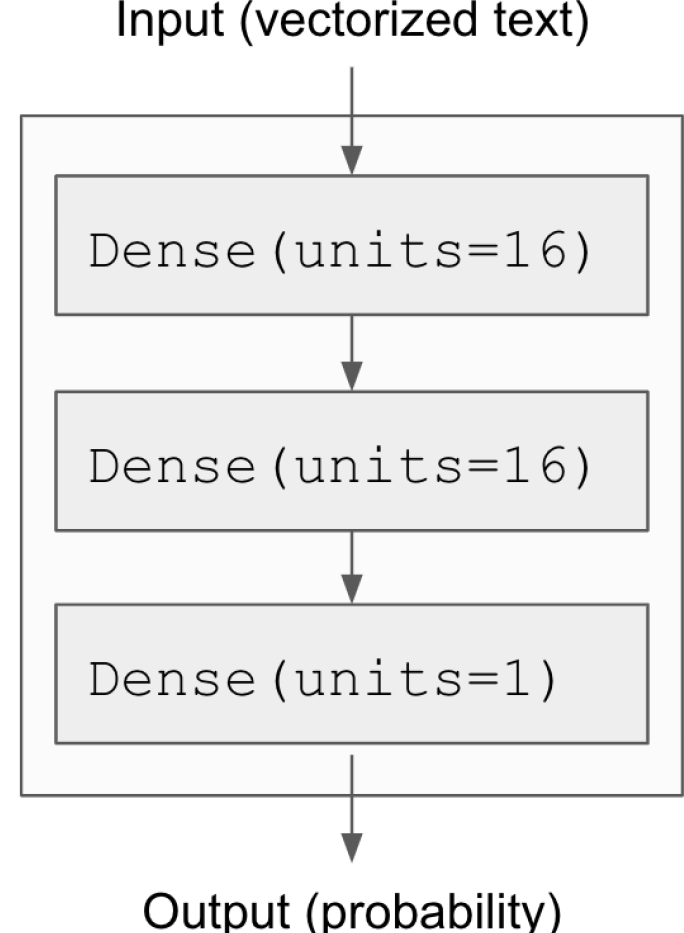

The first argument being passed to each Dense layer is the number of units in the layer: the
dimensionality of representation space of the layer. You remember from chapters 2 and 3
that each such Dense layer with a relu activation implements the following chain of tensor
operations:

output = relu(dot(input, W) + b)

Having 16 units means the weight matrix W will have shape (input_dimension, 16): the
dot product with W will project the input data onto a 16-dimensional representation space
(and then you’ll add the bias vector b and apply the relu operation). You can intuitively
understand the dimensionality of your representation space as “how much freedom you’re
allowing the model to have when learning internal representations.” Having more units (a
higher-dimensional representation space) allows your model to learn more-complex
representations, but it makes the model more computationally expensive and may lead to
learning unwanted patterns (patterns that will improve performance on the training data
but not on the test data).

The intermediate layers use relu as their activation function, and the final layer uses a
sigmoid activation so as to output a probability (a score between 0 and 1, indicating how
likely the review is to be positive). A relu (rectified linear unit) is a function meant to zero
out negative values (see Figure 4.2), whereas a sigmoid “squashes” arbitrary values into
the [0, 1] interval (see Figure 4.3), outputting something that can be interpreted as a
probability.

ReLU:

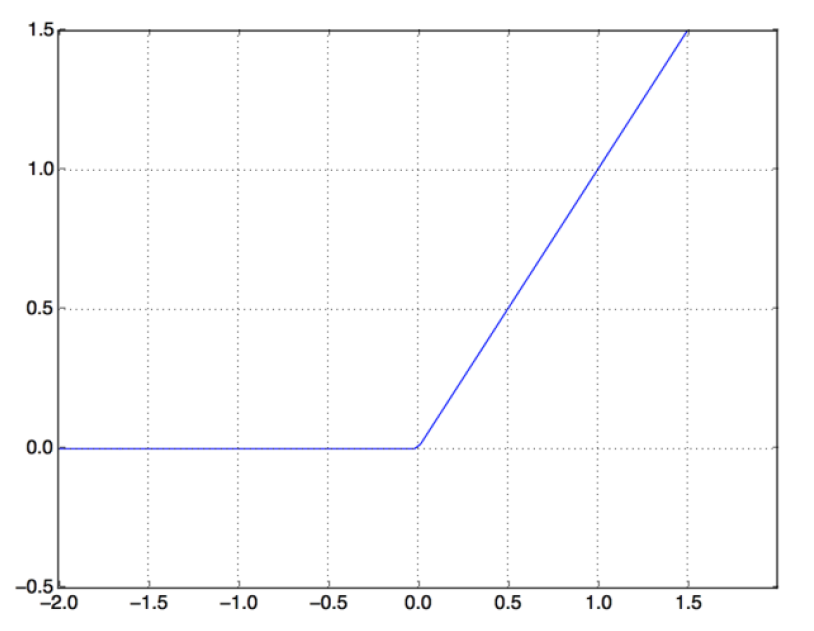

Sigmoid:

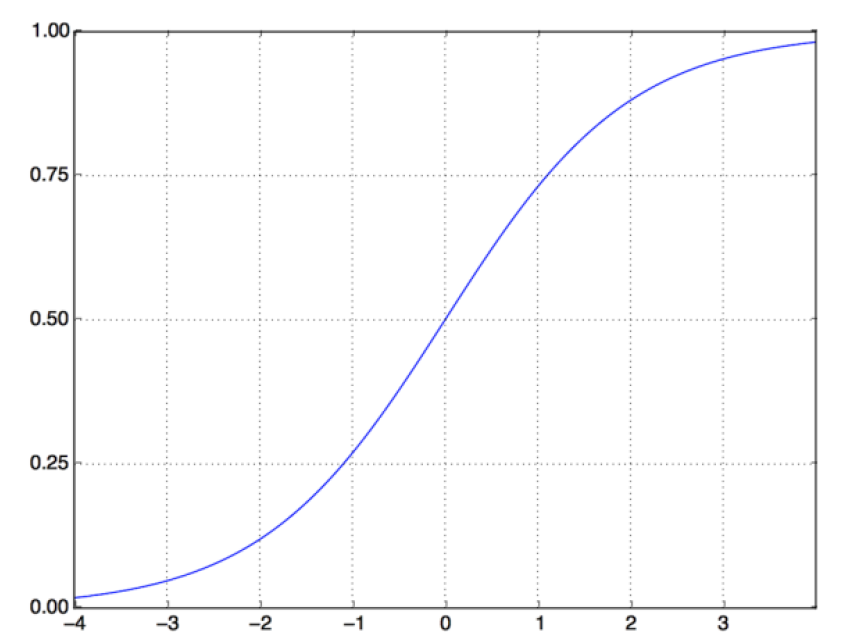

WHAT ARE ACTIVATION FUNCTIONS, AND WHY ARE THEY NECESSARY?

Without an activation function like relu (also called a non-linearity), the Dense layer
would consist of two linear operations – a dot product and an addition:

output = dot(input, W) + b

So the layer could only learn linear transformations (affine transformations) of the
input data: the hypothesis space of the layer would be the set of all possible linear
transformations of the input data into a 16-dimensional space. Such a hypothesis
space is too restricted and wouldn’t benefit from multiple layers of representations,
because a deep stack of linear layers would still implement a linear operation: adding
more layers wouldn’t extend the hypothesis space (as you saw in Chapter 2).

In order to get access to a much richer hypothesis space that would benefit from
deep representations, you need a non-linearity, or activation function. relu is the
most popular activation function in deep learning, but there are many other
candidates, which all come with similarly strange names: prelu, elu, and so on.

Finally, you need to choose a loss function and an optimizer. Because you’re facing a binary
classification problem and the output of your model is a probability (you end your model
with a single-unit layer with a sigmoid activation), it’s best to use the
binary_crossentropy loss. It isn’t the only viable choice: you could use, for instance,
mean_squared_error. But crossentropy is usually the best choice when you’re dealing with
models that output probabilities. Crossentropy is a quantity from the field of Information
Theory that measures the distance between probability distributions or, in this case,
between the ground-truth distribution and your predictions.

As for the choice of the optimizer, we’ll go with adam, which is usually a good default
choice for virtually any problem.

Here’s the step where you configure the model with the adam optimizer and the
binary_crossentropy loss function. Note that you’ll also monitor accuracy during training.

In [100]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

In [101]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

#### Validating your approach

As you learned in Chapter 3, a deep learning model should never be evaluated on its
training data – it’s standard practice to use a “validation set” to monitor the accuracy of the
model during training. Here, you’ll create a validation set by setting apart 10,000 samples
from the original training data.

You might ask, why not simply use the test data to evaluate the model? That seems like
it would be easier. The reason why is that you’re going to want to use the results you get
on the validation set to inform your next choices to improve training – for instance, your
choice of what model size to use or how many epochs to train for. When you start doing
this, your validation scores stop being an accurate reflection of the performance of the
model on brand new data, since the model has been deliberately modified to perform better
on the validation data. It’s good to keep around a set of never-seen-before samples that
you can use to perform the final evaluation round in a completely unbiased way, and that’s
exactly what the test set is. We’ll talk more about this in the next chapter.

In [102]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

You’ll now train the model for 20 epochs (20 iterations over all samples in the training
data), in mini-batches of 512 samples. At the same time, you’ll monitor loss and accuracy
on the 10,000 samples that you set apart. You do so by passing the validation data as the
validation_data argument to model.fit().

In [103]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.7299 - loss: 0.5724 - val_accuracy: 0.8573 - val_loss: 0.4167
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.8964 - loss: 0.3122 - val_accuracy: 0.8859 - val_loss: 0.2988
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9309 - loss: 0.2063 - val_accuracy: 0.8853 - val_loss: 0.2850
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9531 - loss: 0.1524 - val_accuracy: 0.8880 - val_loss: 0.2795
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9673 - loss: 0.1147 - val_accuracy: 0.8866 - val_loss: 0.2946
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9786 - loss: 0.0868 - val_accuracy: 0.8835 - val_loss: 0.3172
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9861 - loss: 0.0647 - val_accuracy: 0.8805 - val_loss: 0.3448
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9925 - loss: 0.0476 - val_accuracy: 0.8782 - v

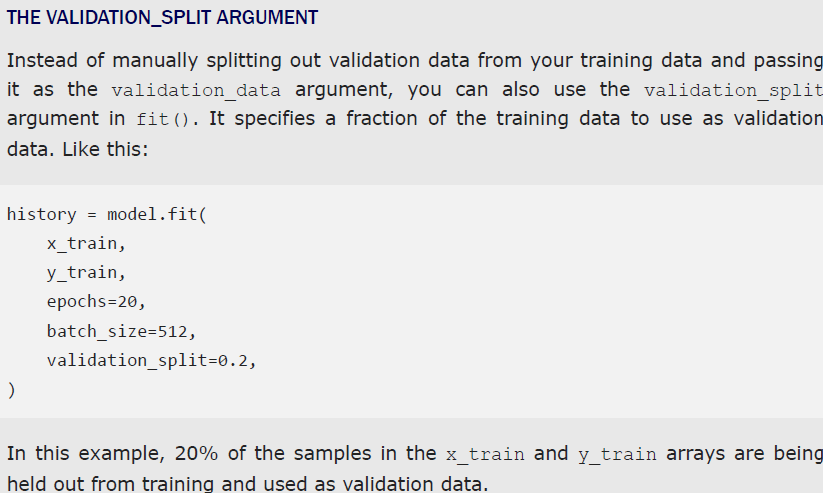

The validation data is selected from the last samples in the x and y data provided, before shuffling.  Make sure your data has been shuffled before using the validation_split parameter.

Note below that running model.fit() again without creating a new model is just adding epochs to the model.  It is not starting over with new random weights and bias values.

In [104]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.2,
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9314 - loss: 0.2679 - val_accuracy: 0.9796 - val_loss: 0.0684
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9628 - loss: 0.1152 - val_accuracy: 0.9736 - val_loss: 0.0822
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9831 - loss: 0.0668 - val_accuracy: 0.9676 - val_loss: 0.0921
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9918 - loss: 0.0458 - val_accuracy: 0.9592 - val_loss: 0.1044
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9958 - loss: 0.0315 - val_accuracy: 0.9562 - val_loss: 0.1195
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9975 - loss: 0.0224 - val_accuracy: 0.9544 - val_loss: 0.1276
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9984 - loss: 0.0167 - val_accuracy: 0.9528 - val_loss: 0.1383
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9991 - loss: 0.0129 - val_accuracy: 0.9506 - val_loss

On CPU, this will take less than 2 seconds per epoch – training is over in 20 seconds. At the
end of every epoch, there is a slight pause as the model computes its loss and accuracy on
the 10,000 samples of the validation data.

Note that the call to model.fit() returns a History object, as you’ve seen in Chapter 3.
This object has a member history, which is a dictionary containing data about everything
that happened during training. Let’s look at it:

In [105]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

The dictionary contains four entries: one per metric that was being monitored during
training and during validation. In the following two listings, let’s use Matplotlib to plot the
training and validation loss side-by-side (see Figure 4.4), as well as the training and
validation accuracy (see Figure 4.5). Note that your own results may vary slightly due to a
different random initialization of your model.

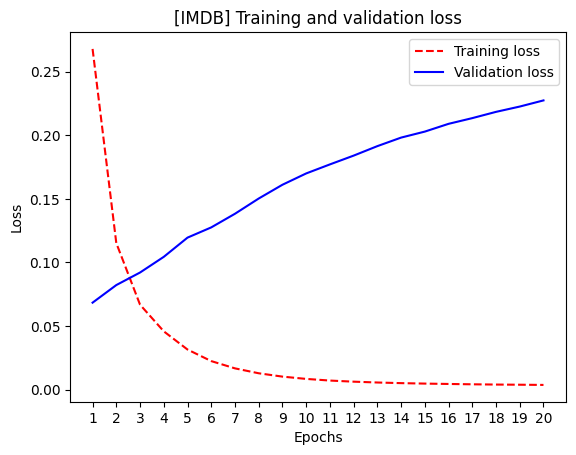

In [106]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("[IMDB] Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.savefig("imdb_loss_plot.png", dpi=300)

### Image from the book:
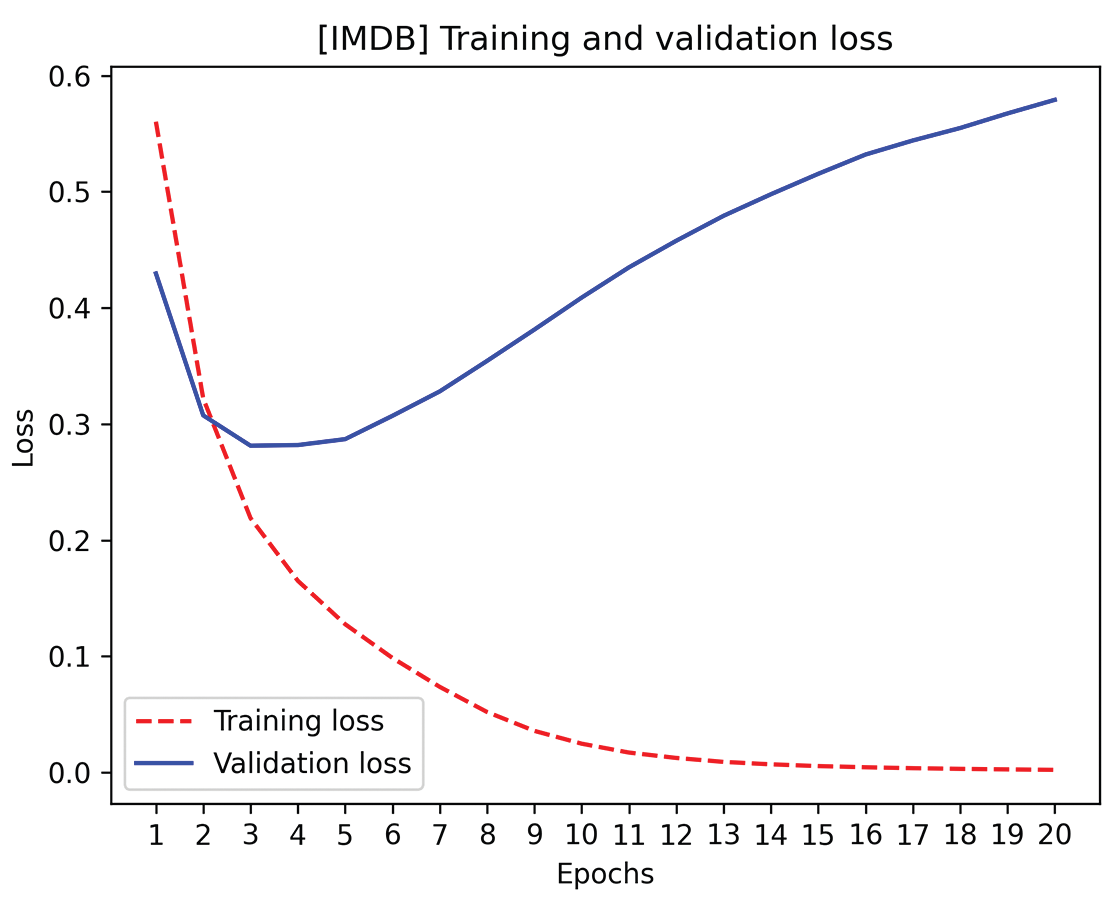

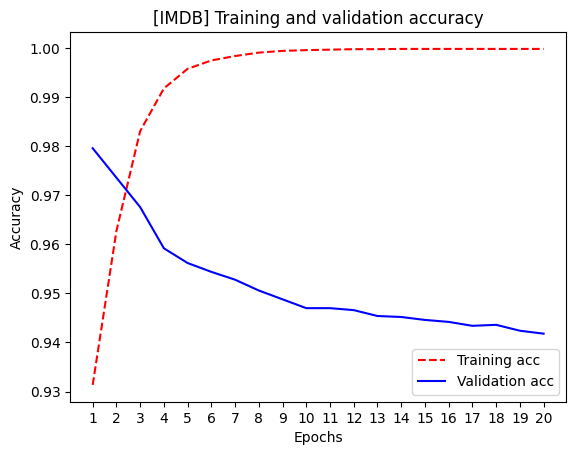

In [107]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("[IMDB] Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("imdb_accuracy_plot.png", dpi=300)

### Image from the book:
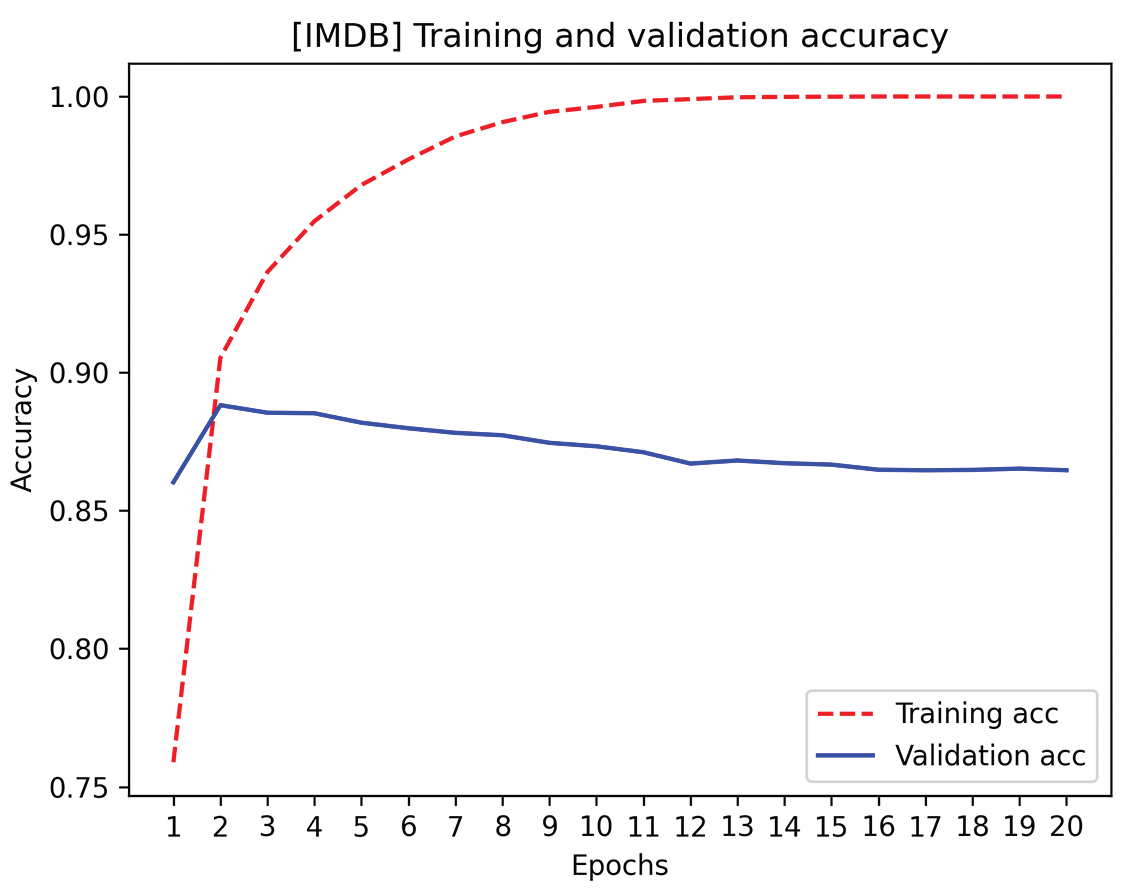

As you can see, the training loss decreases with every epoch, and the training accuracy
increases with every epoch. That’s what you would expect when running gradient-descent
optimization – the quantity you’re trying to minimize should be less with every iteration.
But that isn’t the case for the validation loss and accuracy: they seem to peak at the fourth
epoch. This is an example of what we warned against earlier: a model that performs better
on the training data isn’t necessarily a model that will do better on data it has never seen
before. In precise terms, what you’re seeing is overfitting: after the fourth epoch, you’re
over-optimizing on the training data, and you end up learning representations that are
specific to the training data and don’t generalize to data outside of the training set.

In this case, to prevent overfitting, you could stop training after four epochs. In general,
you can use a range of techniques to mitigate overfitting, which we’ll cover in Chapter 5.

Let’s train a new model from scratch for four epochs and then evaluate it on the test
data.

In [108]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.8150 - loss: 0.4771
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9128 - loss: 0.2467
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9348 - loss: 0.1846
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9489 - loss: 0.1488
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8811 - loss: 0.3050


In [109]:
results  # first number is loss for the test data, the second number is accuracy for the test data

[0.3050113320350647, 0.881119966506958]

#### Using a trained model to generate predictions on new data

After having trained a model, you’ll want to use it in a practical setting. You can generate
the likelihood of reviews being positive by using the predict method, as you’ve learned in
Chapter 3:

In [110]:
model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


array([[0.18413253],
       [0.9992464 ],
       [0.77682674],
       ...,
       [0.08445274],
       [0.07574724],
       [0.59697425]], dtype=float32)

As you can see, the model is confident for some samples (0.99 or more, or 0.01 or less)
but less confident for others (0.6, 0.4).

#### Further experiments

The following experiments will help convince you that the architecture choices you’ve made
are all fairly reasonable, although there’s still room for improvement:

You used two representation layers before the final classification layer. Try
using one or three representation layers, and see how doing so affects
validation and test accuracy.

Try using layers with more units or fewer units: 32 units, 64 units, and so
on.

Try using the mean_squared_error loss function instead of
binary_crossentropy.

Try using the tanh activation (an activation that was popular in the early
days of neural networks) instead of relu.

#### Wrapping up

Here’s what you should take away from this example:

You usually need to do quite a bit of preprocessing on your raw data in
order to be able to feed it – as tensors – into a neural network.
Sequences of words can be encoded as binary vectors, but there are
other encoding options, too.

Stacks of Dense layers with relu activations can solve a wide range of
problems (including sentiment classification), and you’ll use them
frequently.

In a binary classification problem (two output classes), your model should
end with a Dense layer with one unit and a sigmoid activation: the output
of your model should be a scalar between 0 and 1, encoding a probability.
With such a scalar sigmoid output on a binary classification problem, the
loss function you should use is binary_crossentropy.

The adam optimizer is generally a good enough choice, whatever your
problem. That’s one less thing for you to worry about.

As they get better on their training data, neural networks eventually start
overfitting and end up obtaining increasingly worse results on data
they’ve never seen before. Be sure to always monitor performance on
data that is outside of the training set!

### Classifying newswires: a multiclass classification example

In the previous section, you saw how to classify vector inputs into two mutually exclusive
classes using a densely-connected neural network. But what happens when you have more
than two classes?

In this section, you’ll build a model to classify Reuters newswires into 46 mutually
exclusive topics. Because you have many classes, this problem is an instance of multiclass
classification; and because each data point should be classified into only one category, the
problem is more specifically an instance of single-label, multiclass classification. If each
data point could belong to multiple categories (in this case, topics), you’d be facing a
multilabel, multiclass classification problem.

#### The Reuters dataset

You’ll work with the Reuters dataset, a set of short newswires and their topics, published by
Reuters in 1986. It’s a simple, widely used toy dataset for text classification. There are 46
different topics; some topics are more represented than others, but each topic has at least
10 examples in the training set.

Like IMDb and MNIST, the Reuters dataset comes packaged as part of Keras. Let’s take a
look.

In [111]:
from keras.datasets import reuters

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
    num_words=10000
)

As with the IMDb dataset, the argument num_words=10000 restricts the data to the 10,000
most frequently occurring words found in the data.

You have 8,982 training examples and 2,246 test examples:

In [112]:
len(train_data)

8982

In [113]:
len(test_data)

2246

In [114]:
train_data[10]

[1,
 245,
 273,
 207,
 156,
 53,
 74,
 160,
 26,
 14,
 46,
 296,
 26,
 39,
 74,
 2979,
 3554,
 14,
 46,
 4689,
 4329,
 86,
 61,
 3499,
 4795,
 14,
 61,
 451,
 4329,
 17,
 12]

In [115]:
# decode back to words
word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_newswire = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[10]]
)

In [116]:
train_labels[10]  # value from 0 to 45, the topic index

np.int64(3)

#### Preparing the data

You can vectorize the data with the exact same code as in the previous example.

In [117]:
x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000)

To vectorize the labels, there are two possibilities: you can leave the labels untouched as
integers, or you can use one-hot encoding. One-hot encoding is a widely used format for
categorical data, also called categorical encoding. In this case, one-hot encoding of the
labels consists of embedding each label as an all-zero vector with a 1 in the place of the
label index. Here’s an example:

In [118]:
def one_hot_encode(labels, num_classes=46):
    results = np.zeros((len(labels), num_classes))
    for i, label in enumerate(labels):
        results[i, label] = 1.0
    return results

y_train = one_hot_encode(train_labels)
y_test = one_hot_encode(test_labels)

Note that there is a built-in way to do this in Keras:

In [119]:
from keras.utils import to_categorical

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

#### Building your model

This topic-classification problem looks similar to the previous movie-review classification
problem: in both cases, you’re trying to classify short snippets of text. But there is a new
constraint here: the number of output classes has gone from 2 to 46. The dimensionality of
the output space is much larger.

In a stack of Dense layers like those you’ve been using, each layer can only access
information present in the output of the previous layer. If one layer drops some information
relevant to the classification problem, this information can never be recovered by later
layers: each layer can potentially become an information bottleneck. In the previous
example, you used 16-dimensional intermediate layers, but a 16-dimensional space may be
too limited to learn to separate 46 different classes: such small layers may act as
information bottlenecks, permanently dropping relevant information.

For this reason you’ll use larger intermediate layers. Let’s go with 64 units.

In [120]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)

There are two other things you should note about this architecture:

¡ You end the model with a Dense layer of size 46. This means for each input sample,
the network will output a 46-dimensional vector. Each entry in this vector
(each dimension) will encode a different output class.

¡ The last layer uses a softmax activation. You saw this pattern in the MNIST example.
It means the model will output a probability distribution over the 46 different
output classes—for every input sample, the model will produce a 46-dimensional
output vector, where output[i] is the probability that the sample belongs to class
i. The 46 scores will sum to 1.

The best loss function to use in this case is categorical_crossentropy. It measures the
distance between two probability distributions—here, between the probability distribution
outputted by the model and the true distribution of the labels. By minimizing
the distance between these two distributions, you train the model to output something
as close as possible to the true labels.

Like last time, we’ll also monitor accuracy. However, accuracy is a bit of a crude
metric in this case: if the model has the correct class as its second choice for a given
sample, with an incorrect first choice, the model will still have an accuracy of zero on
that sample—even though such a model would be much better than a random guess.
A more nuanced metric in this case is top-k accuracy, such as top-3 or top-5 accuracy. It
measures whether the correct class was among the top-k predictions of the model. Let’s
add top-3 accuracy to our model.

In [121]:
top_3_accuracy = keras.metrics.TopKCategoricalAccuracy(
    k=3, name="top_3_accuracy"
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy", top_3_accuracy],
)

#### Validating your approach

Let’s set apart 1,000 samples in the training data to use as a validation set.

In [122]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

In [123]:
# train for 20 epochs
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 263ms/step - accuracy: 0.3463 - loss: 3.3242 - top_3_accuracy: 0.5669 - val_accuracy: 0.5060 - val_loss: 2.6074 - val_top_3_accuracy: 0.6570
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5580 - loss: 2.1226 - top_3_accuracy: 0.6753 - val_accuracy: 0.5990 - val_loss: 1.7388 - val_top_3_accuracy: 0.7260
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6645 - loss: 1.4926 - top_3_accuracy: 0.7700 - val_accuracy: 0.6770 - val_loss: 1.4067 - val_top_3_accuracy: 0.7760
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7337 - loss: 1.1753 - top_3_accuracy: 0.8166 - val_accuracy: 0.7340 - val_loss: 1.2362 - val_top_3_accuracy: 0.8110
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7860 - loss: 0.9472 - top_3_accuracy: 0.8676 - val_accuracy: 0.7480 - val_loss: 1.1164 - val_top_3_accuracy: 0.8480
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8314 - loss: 0.7572 - top_3_a

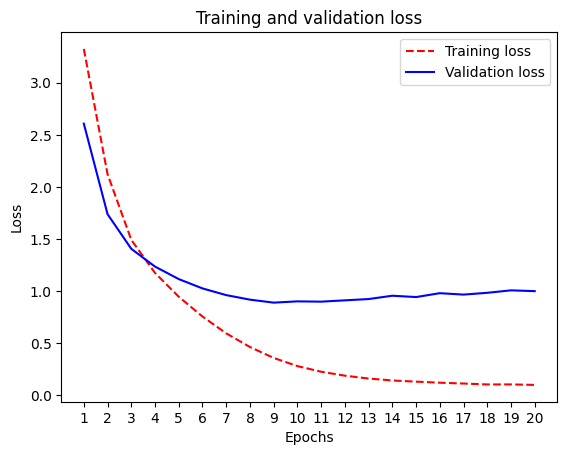

In [124]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.savefig("reuters_loss_plot.png", dpi=300)

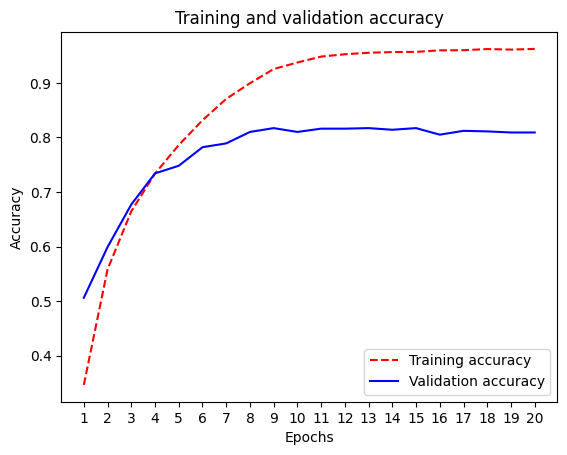

In [125]:
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("reuters_accuracy_plot.png", dpi=300)

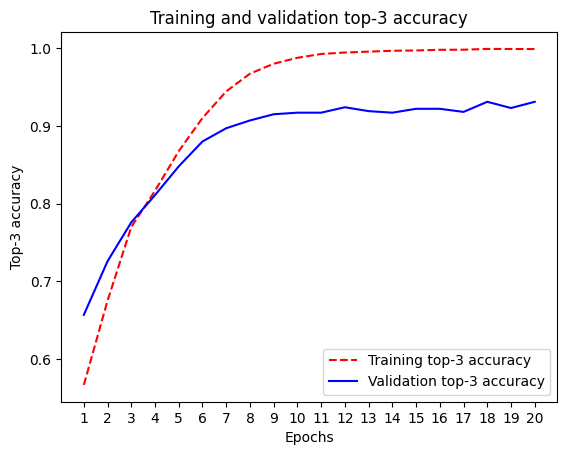

In [126]:
plt.clf()
acc = history.history["top_3_accuracy"]
val_acc = history.history["val_top_3_accuracy"]
plt.plot(epochs, acc, "r--", label="Training top-3 accuracy")
plt.plot(epochs, val_acc, "b", label="Validation top-3 accuracy")
plt.title("Training and validation top-3 accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Top-3 accuracy")
plt.legend()
plt.savefig("reuters_top_3_accuracy_plot.png", dpi=300)

The model begins to overfit after nine epochs. Let’s train a new model from scratch for nine
epochs and then evaluate it on the test set.

In [127]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    x_train,
    y_train,
    epochs=9,
    batch_size=512,
)
results = model.evaluate(x_test, y_test)

Epoch 1/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.4517 - loss: 3.1322
Epoch 2/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6271 - loss: 1.8032
Epoch 3/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7164 - loss: 1.3005
Epoch 4/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7770 - loss: 1.0137
Epoch 5/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8331 - loss: 0.7894
Epoch 6/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8736 - loss: 0.6079
Epoch 7/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9029 - loss: 0.4663
Epoch 8/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9259 - loss: 0.3599
Epoch 9/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9413 - loss: 0.2825
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7952 - loss: 0.9296


In [128]:
results  # 79% accuracy on the validation set

[0.9296449422836304, 0.7951914668083191]

This approach reaches an accuracy of approximately 80%. With a balanced binary
classification problem, the accuracy reached by a purely random classifier would be 50%.

But in this case, we have 46 classes, and they may not be equally represented. What would
be the accuracy of a random baseline? We could try quickly implementing one to check this
empirically:

As you can see, a random classifier would score around 19% classification accuracy, so the
results of our model seem pretty good in that light.

In [129]:
import copy
test_labels_copy = copy.copy(test_labels)
np.random.shuffle(test_labels_copy)
hits_array = np.array(test_labels)
hits_array.mean()

np.float64(8.913178984861977)

#### Generating predictions on new data

Calling the model’s predict method on new samples returns a class probability distribution
over all 46 topics for each sample. Let’s generate topic predictions for all of the test data.

In [130]:
predictions = model.predict(x_test)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [131]:
predictions[0].shape

(46,)

In [132]:
np.sum(predictions[0])  # probability distribution adds to one

np.float32(1.0000001)

In [133]:
np.argmax(predictions[0])  # largest value is predicted class

np.int64(3)

#### A different way to handle the labels and the loss

We mentioned earlier that another way to encode the labels would be to leave them
untouched as integer tensors, like this:

In [134]:
y_train = np.array(train_labels)
y_test = np.array(test_labels)

The only thing this approach would change is the choice of the loss function. The loss
function used in Listing 4.22, categorical_crossentropy, expects the labels to follow a
categorical encoding. With integer labels, you should use
sparse_categorical_crossentropy:

This new loss function is still mathematically the same as categorical_crossentropy; it
just has a different interface.

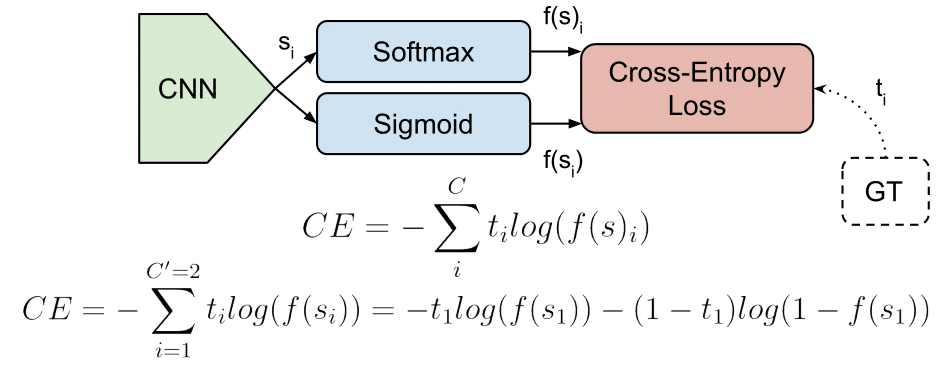

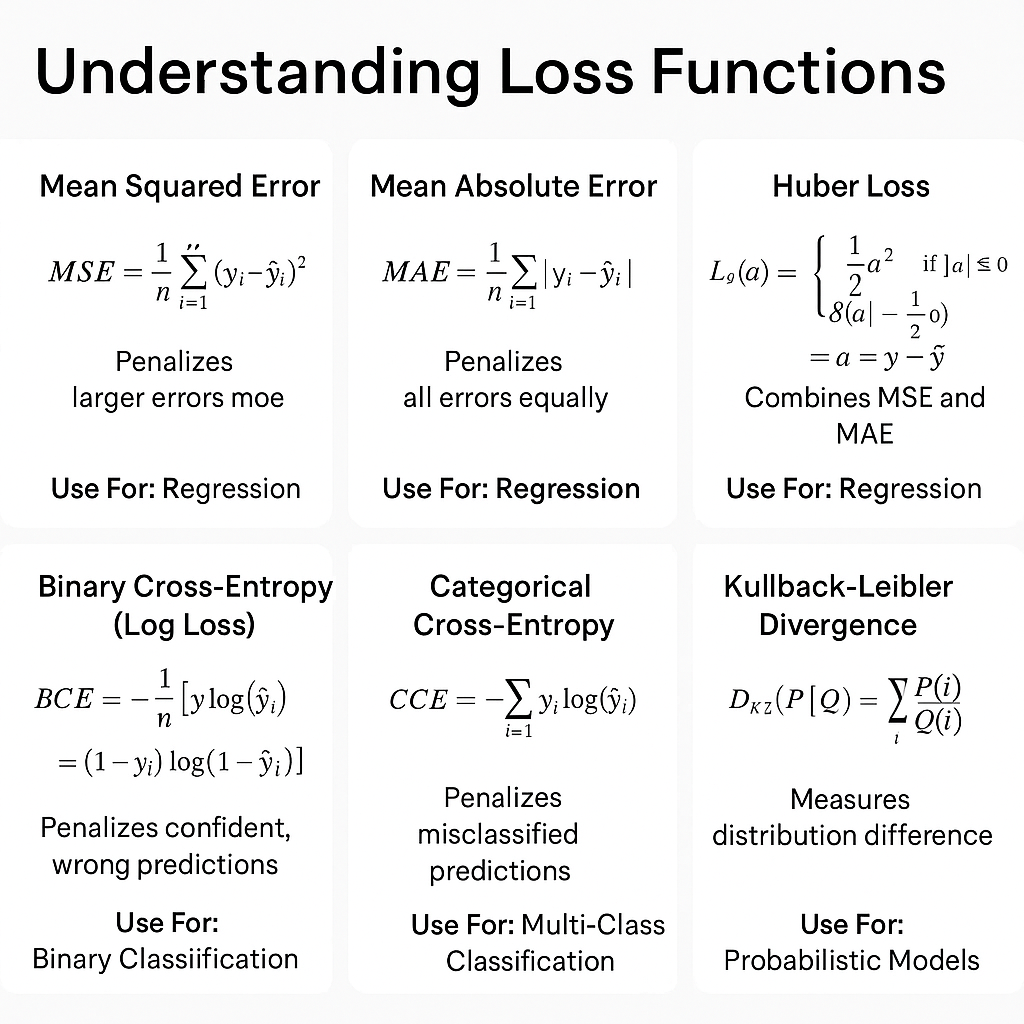

In [135]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

#### The importance of having sufficiently large intermediate layers

We mentioned earlier that because the final outputs are 46-dimensional, you should avoid
intermediate layers with many fewer than 46 units. Now let’s see what happens when you
introduce an information bottleneck by having intermediate layers that are significantly less
than 46-dimensional: for example, 4-dimensional.

In [136]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val),
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.1101 - loss: 3.2527 - val_accuracy: 0.4880 - val_loss: 2.4514
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5411 - loss: 1.9241 - val_accuracy: 0.5700 - val_loss: 1.7262
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6120 - loss: 1.4836 - val_accuracy: 0.6290 - val_loss: 1.4979
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6953 - loss: 1.2001 - val_accuracy: 0.6650 - val_loss: 1.3955
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7402 - loss: 1.0145 - val_accuracy: 0.6810 - val_loss: 1.3611
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7769 - loss: 0.8828 - val_accuracy: 0.6940 - val_loss: 1.3429
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8022 - loss: 0.7817 - val_accuracy: 0.7060 - val_loss: 1.3466
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8236 - loss: 0.7109 - val_accuracy: 0.7090 - val_loss

The model now peaks at approximately 71% validation accuracy, an 8% absolute drop. This
drop is mostly due to the fact that you’re trying to compress a lot of information (enough
information to recover the separation hyperplanes of 46 classes) into an intermediate space
that is too low-dimensional. The model is able to cram most of the necessary information
into these four-dimensional representations, but not all of it.

#### Further experiments

Try using larger or smaller layers: 32 units, 128 units, and so on.

You used two intermediate layers before the final softmax classification
layer. Now try using a single intermediate layer, or three intermediate
layers.

Resample the data since many classes are underrepresented.

#### Wrapping up

Here’s what you should take away from this example:

If you’re trying to classify data points among N classes, your model
should end with a Dense layer of size N.

In a single-label, multiclass classification problem, your model should end
with a softmax activation so that it will output a probability distribution
over the N output classes.

Categorical crossentropy is almost always the loss function you should
use for such problems. It minimizes the distance between the probability
distributions output by the model and the true distribution of the targets.

There are two ways to handle labels in multiclass classification:

Encoding the labels via categorical encoding (also known as
one-hot encoding) and using categorical_crossentropy
as a loss function

Encoding the labels as integers and using the
sparse_categorical_crossentropy loss function

If you need to classify data into a large number of categories, you should
avoid creating information bottlenecks

### Predicting house prices: a regression example

The two previous examples were considered classification problems, where the goal was to
predict a single discrete label of an input data point. Another common type of machinelearning
problem is regression, which consists of predicting a continuous value instead of a
discrete label: for instance, predicting the temperature tomorrow given meteorological
data, or predicting the time that a software project will take to complete given its
specifications.

#### The California Housing Price dataset

You’ll attempt to predict the median price of homes in different areas of California, based
on data from the 1990 census.

Each data point in the dataset represents information about a “block group”, a group of
homes located in the same area. You can think of it as a district. This dataset has two
versions, the “small” version with just 600 districts, and the “large” version with 20,640
districts. Let’s use the small version, because real-world datasets can often be tiny, and you
need to know how to handle such cases.

For each district, we know:

The longitude and latitude of the approximate geographic center of the
area.

The median age of houses in the district.

The population of the district. The districts are pretty small: the average
population is 1425.5.

The total number of households.

The median income of those households.

The total number of rooms in the district, across all homes located there.
This is typically in the low thousands.

The total number of bedrooms in the district.

That’s eight variables in total (longitude & latitude counts as two variables). The goal is to
use these variables to predict the median value of the houses in the district. Let’s get
started by loading the data.

In [137]:
from keras.datasets import california_housing

(train_data, train_targets), (test_data, test_targets) = (
    california_housing.load_data(version="small")
)

743530/743530 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [138]:
train_data.shape  # 480 training samples with 8 features

(480, 8)

In [139]:
test_data.shape

(120, 8)

In [140]:
train_targets   # home prices (in thousands of dollars)

array([228400., 132900.,  60000.,  95200., 107000., 122500., 132000.,
       290100., 257800., 390100., 220800., 284900.,  97500., 415300.,
        84200., 185600., 216700., 233100., 127000., 182300.,  92300.,
        90700., 102100., 112500., 350700., 156500., 220700., 147400.,
       216700., 275000., 198200., 119100., 289500., 152500., 125000.,
       104500.,  93800.,  89300., 452600., 128600., 311500.,  90000.,
       218200., 131300.,  67500., 139400., 500001., 182600., 111300.,
       112500., 134700.,  71300., 207400., 331400., 107900.,  87500.,
       342200.,  87100., 314700., 368600., 211600., 338900., 366100.,
       164300.,  91700., 261400., 218500., 155400., 273700.,  81800.,
       138800.,  99700., 156300., 140600., 152700., 108900., 351200.,
       126000., 137500., 196900., 240000., 172800., 254200.,  97500.,
       182700., 162500.,  86100., 226700., 412500., 165900., 327100.,
       162500., 188800., 183800.,  90600., 372000., 275000., 151800.,
       125000., 1291

#### Preparing the data

It would be problematic to feed into a neural network values that all take wildly different
ranges. The model might be able to automatically adapt to such heterogeneous data, but it
would definitely make learning more difficult. A widespread best practice to deal with such
data is to do feature-wise normalization: for each feature in the input data (a column in the
input data matrix), you subtract the mean of the feature and divide by the standard
deviation, so that the feature is centered around 0 and has a unit standard deviation. This
is easily done in NumPy.

In [141]:
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)
x_train = (train_data - mean) / std
x_test = (test_data - mean) / std

Note that the quantities used for normalizing the test data are computed using the training
data. You should never use in your workflow any quantity computed on the test data, even
for something as simple as data normalization.

In addition, we should also scale the targets. Our normalized inputs have their value in a
small range close to 0, and our model’s weights are initialized with small random values.
This means that our model’s prediction will also be small values when we start training. If
the targets are in the range 60,000-500,000, the model is going to need very large weight
values to output those. With a small learning rate, it would take a very long time to get
there. The simplest fix is to divide all target values by 100,000, so that the smallest target
becomes 0.6, and the largest becomes 5. We can then convert the model’s predictions back
to dollar values by multiplying them by 100,000 accordingly.

In [142]:
y_train = train_targets / 100000
y_test = test_targets / 100000

#### Building your model

Because so few samples are available, you’ll use a very small model with two intermediate
layers, each with 64 units. In general, the less training data you have, the worse overfitting
will be, and using a small model is one way to mitigate overfitting.

In [143]:
def get_model():
    model = keras.Sequential(
        [
            layers.Dense(64, activation="relu"),
            layers.Dense(64, activation="relu"),
            layers.Dense(1),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="mean_squared_error",
        metrics=["mean_absolute_error"],
    )
    return model

The model ends with a single unit and no activation: it will be a linear layer. This is a typical
setup for scalar regression – a regression where you’re trying to predict a single continuous
value. Applying an activation function would constrain the range the output can take; for
instance, if you applied a sigmoid activation function to the last layer, the model could only
learn to predict values between 0 and 1. Here, because the last layer is purely linear, the
model is free to learn to predict values in any range.

Note that you compile the model with the mean_squared_error loss function – mean
squared error, the square of the difference between the predictions and the targets. This is
a widely used loss function for regression problems.

You’re also monitoring a new metric during training: mean absolute error (MAE). It’s the
absolute value of the difference between the predictions and the targets. For instance, an
MAE of 0.5 on this problem would mean your predictions are off by $50,000 on average
(remember the target scaling of factor 100,000).

#### Validating your approach using K-fold validation

To evaluate your model while you keep adjusting its parameters (such as the number of
epochs used for training), you could split the data into a training set and a validation set, as
you did in the previous examples. But because you have so few data points, the validation
set would end up being very small (for instance, about 100 examples). As a consequence,
the validation scores might change a lot depending on which data points you chose to use
for validation and which you chose for training: the validation scores might have a high
variance with regard to the validation split. This would prevent you from reliably evaluating
your model.
The best practice in such situations is to use K-fold cross-validation (see Figure 4.9). It
consists of splitting the available data into K partitions (typically K = 4 or 5), instantiating K
identical models, and training each one on K – 1 partitions while evaluating on the
remaining partition. The validation score for the model used is then the average of the K
validation scores obtained. In terms of code, this is straightforward.

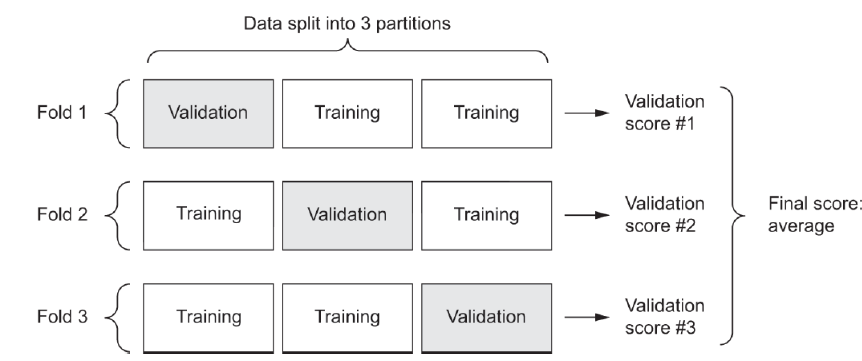


In [144]:
k = 4
num_val_samples = len(x_train) // k
num_epochs = 50
all_scores = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()
    model.fit(
        fold_x_train,
        fold_y_train,
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
    )
    scores = model.evaluate(fold_x_val, fold_y_val, verbose=0)
    val_loss, val_mae = scores
    all_scores.append(val_mae)

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


Do not forget to create a new model with each fold.  If you just do model.fit() with each fold, all you are doing is running more epochs on the same model and updating the same weights and bias'.  The fourth model will be better because it is the first model with many more epochs of training.

In [145]:
[round(value, 3) for value in all_scores]

[0.283, 0.287, 0.232, 0.305]

The different runs do indeed show meaningfully different validation scores, from 0.232 to
0.349. The average (0.296) is a much more reliable metric than any single score – that’s
the entire point of K-fold cross-validation. In this case, you’re off by \\$29,600 on average,
which is significant considering that the prices range from \\$60,000 to \\$500,000.

Let’s try training the model a bit longer: 200 epochs. To keep a record of how well the
model does at each epoch, you’ll modify the training loop to save the per-epoch validation
score log.

In [146]:
round(np.mean(all_scores), 3)

np.float64(0.277)

In [147]:
k = 4
num_val_samples = len(x_train) // k
num_epochs = 200
all_mae_histories = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()
    history = model.fit(
        fold_x_train,
        fold_y_train,
        validation_data=(fold_x_val, fold_y_val),
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
    )
    mae_history = history.history["val_mean_absolute_error"]
    all_mae_histories.append(mae_history)

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


In [148]:
average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)
]

You can then compute the average of the per-epoch Mean Absolute Error scores for all
folds.

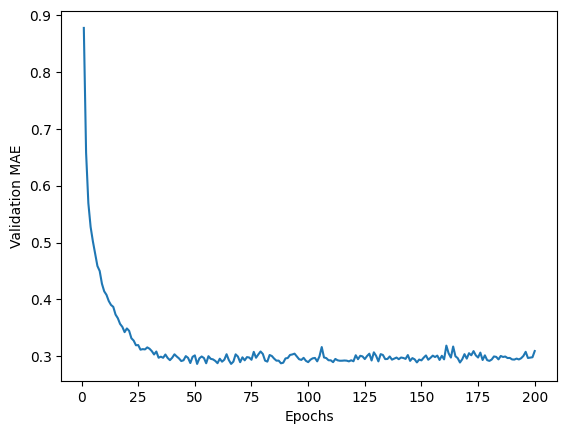

In [149]:
epochs = range(1, len(average_mae_history) + 1)
plt.plot(epochs, average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.savefig("california_housing_validation_mae_plot.png", dpi=300)

Omitting the first 10 epochs so the scale makes the data more readable

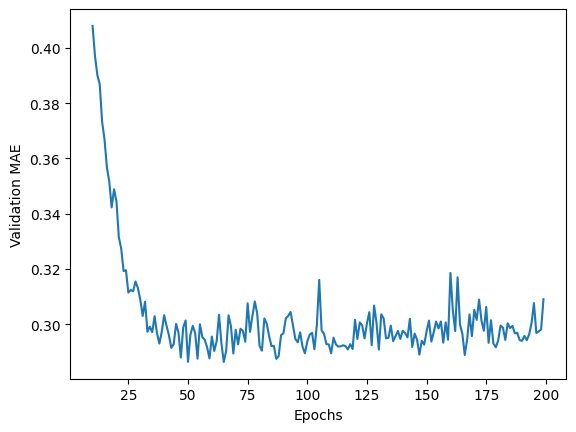

In [150]:
truncated_mae_history = average_mae_history[10:]
epochs = range(10, len(truncated_mae_history) + 10)
plt.plot(epochs, truncated_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.savefig("california_housing_validation_mae_plot_zoomed.png", dpi=300)

According to this plot, validation MAE stops improving significantly after 120-140 epochs
(this number includes the 10 epochs we omitted). Past that point, you start overfitting.

Once you’re finished tuning other parameters of the model (in addition to the number of
epochs, you could also adjust the size of the intermediate layers), you can train a final
production model on all of the training data, with the best parameters, and then look at its
performance on the test data.

In [151]:
model = get_model()  # start over with fresh weights and biases
model.fit(x_train, y_train, epochs=130, batch_size=16, verbose=0)  # fit on all training data
test_mean_squared_error, test_mean_absolute_error = model.evaluate(
    x_test, y_test
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.2967 - mean_absolute_error: 0.3178


In [152]:
round(test_mean_absolute_error, 3)

0.318

We’re still off by about $31,000 on average.

#### Generating predictions on new data

When calling predict() on our binary classification model, we retrieved a scalar score
between 0 and 1 for each input sample. With our multi-class classification model, we
retrieved a probability distribution over all classes for each sample. Now, with this scalar
regression model, predict() returns the model’s guess for the sample’s price in hundreds
of thousands of dollars:

In [153]:
predictions = model.predict(test_data)
predictions[0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


array([1714.2087], dtype=float32)

The first district in the test set is predicted to have an average home price of about
$283,000.

#### Wrapping up

Here’s what you should take away from this scalar regression example:
Regression is done using different loss functions than what we used for
classification. Mean squared error (MSE) is a loss function commonly used
for regression.

Similarly, evaluation metrics to be used for regression differ from those
used for classification; naturally, the concept of accuracy doesn’t apply for
regression. A common regression metric is mean absolute error (MAE).
When features in the input data have values in different ranges, each
feature should be scaled independently as a preprocessing step.

When there is little data available, using K-fold validation is a great way
to reliably evaluate a model.

When little training data is available, it’s preferable to use a small model
with few intermediate layers (typically only one or two), in order to avoid
severe overfitting.

### Chapter summary

The three most common kinds of machine-learning tasks on vector data
are binary classification, multiclass classification, and scalar regression.

The “Wrapping up” sections earlier in the chapter
summarize the important points you’ve learned regarding
each task.

Each task uses different loss functions.

binary_crossentropy for binary classification.

categorical_crossentropy for multiclass
classification.

mean_squared_error for scalar regression.

You’ll usual ly need to preprocess raw data before feeding it into a neural
network.

When your data has features with different ranges, scale each feature
independently as part of preprocessing.

As training progresses, neural networks eventually begin to overfit and
obtain worse results on never-before-seen data.

If you don’t have much training data, use a small model with only one or
two intermediate layers, to avoid severe overfitting.

If your data is divided into many categories, you may cause information
bottlenecks if you make the intermediate layers too small.

When you’re working with little data, K-fold validation can help reliably
evaluate your model.

# Table of different model types:

If your Yi's are one-hot encoded, use categorical_crossentropy. Examples (for a 3-class classification): [1,0,0] , [0,1,0], [0,0,1]

But if your Yi's are integers, use sparse_categorical_crossentropy. Examples for above 3-class classification problem: [1] , [2], [3]

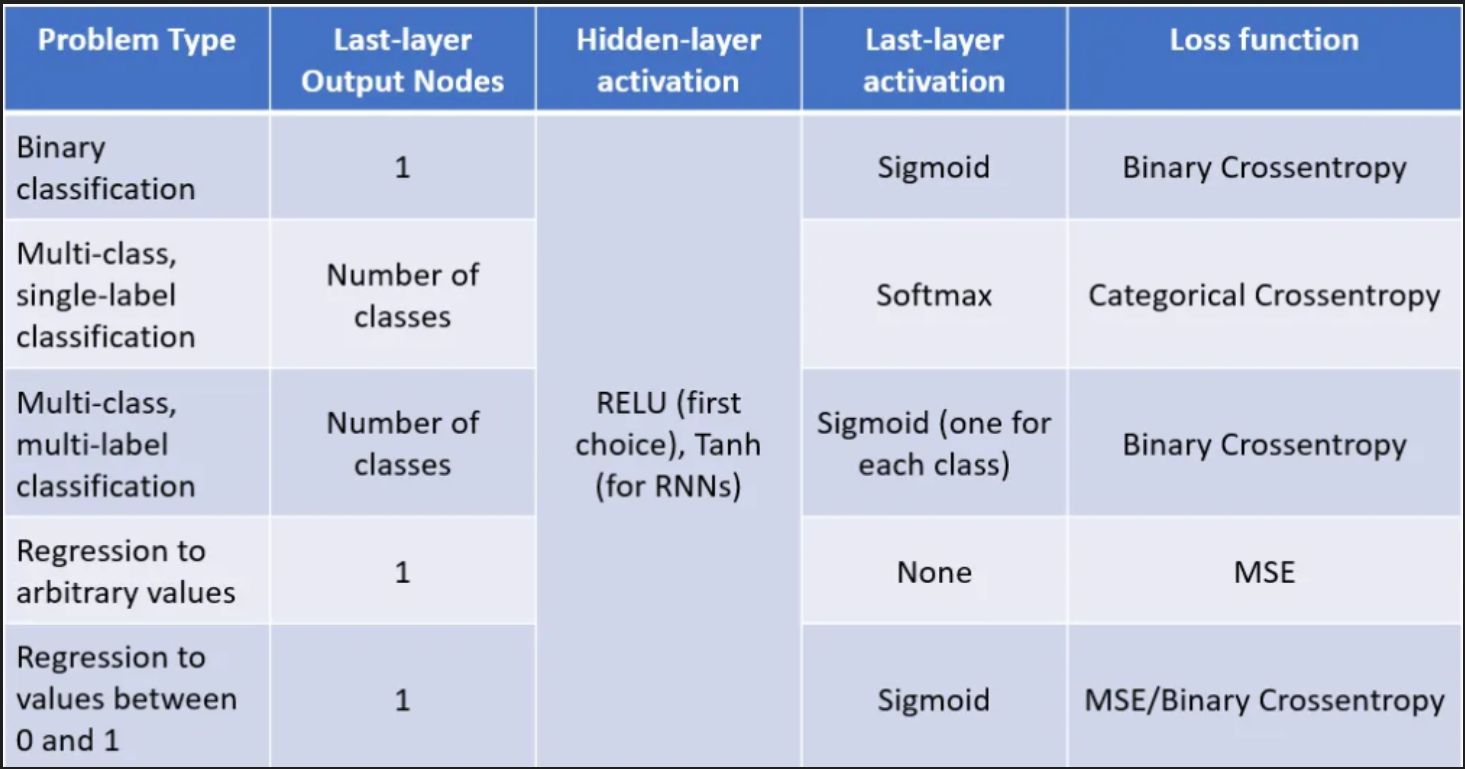